In [1]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd

X,y = make_classification(n_samples=100,n_features=2,n_informative=1,
                          n_redundant=0,n_classes=2,n_clusters_per_class=1,
                          random_state=41,hypercube=False,class_sep=15)

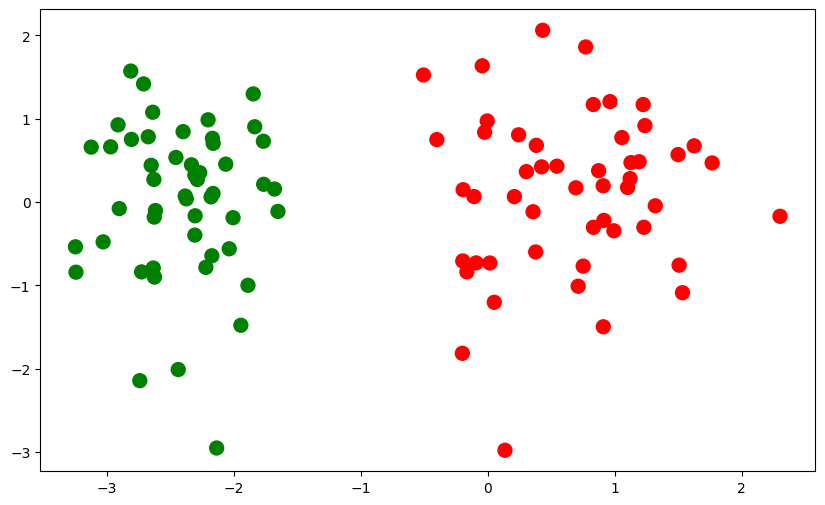

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
a = X[:,0]
b = X[:,1]
colors = ['green' if i == 0 else 'red' for i in y]
plt.scatter(a,b,color=colors,s=100)
plt.show()

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    #The output is now between 0 and 1, so it can be interpreted as a probability.

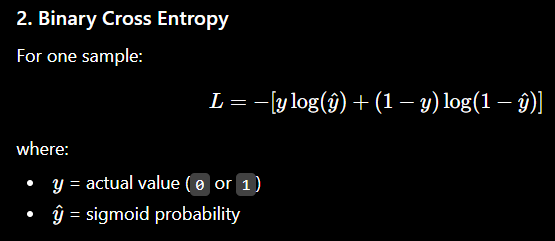

In [4]:
def binary_cross_entropy(y,y_pred):
  epsilon = 1e-15
  y_pred = np.clip(y_pred,epsilon,1-epsilon)

  return -(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
  #The clip prevents problems with log(0).

In [5]:
def logistic_regression_sgd(X,y,lr=0.01,epochs=100):
  w1=w2=b=1
  n= X.shape[0]

  for epoch in range(epochs):
    for i in range(n):
      # 1. Linear combination
      z = w1*X[i][0] + w2*X[i][1] + b

      #2. Sigmoid activation
      y_pred = sigmoid(z)

      #3. Gradient
      error = y_pred -y[i]

      dw1 = error * X[i][0]
      dw2 = error * X[i][1]
      db = error
      #4. SGD update
      w1 = w1 -lr*dw1
      w2 = w2 -lr*dw2
      b = b-lr*db
  return w1,w2,b

In [6]:
w1,w2,b = logistic_regression_sgd(X,y)
print(w1,w2,b)

3.4677774329505064 0.09405442197069365 2.9036035818903616


In [7]:
z = w1*X[:,0] + w2*X[:,1] +b
probabilities = sigmoid(z)
print(probabilities[:10])

[0.98408567 0.92504314 0.89554301 0.00318203 0.94793806 0.05151511
 0.00212009 0.97848877 0.82887479 0.00115061]


In [8]:
y_pred = (probabilities >= 0.5).astype(int)
print(y_pred[:10])

[1 1 1 0 1 0 0 1 1 0]


In [13]:
print("Actual:   ", y[:10])
print("Predicted:", y_pred[:10])

Actual:    [1 1 1 0 1 0 0 1 1 0]
Predicted: [1 1 1 0 1 0 0 1 1 0]


In [15]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y, y_pred))

1.0


In [16]:
loss = binary_cross_entropy(y, probabilities)

print("Final Loss:", np.mean(loss))

Final Loss: 0.020204409779858278


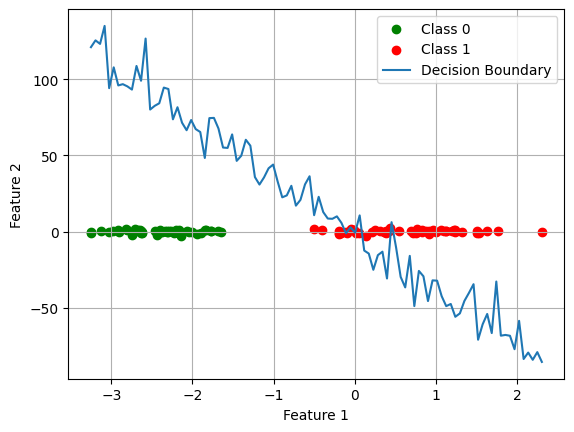

In [17]:
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

x2 = -(w1 * x1 + b) / w2

plt.scatter(X[y == 0, 0], X[y == 0, 1],
            color="green", label="Class 0")

plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color="red", label="Class 1")

plt.plot(x1, x2, label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.show()

Model makes prediction

        ↓

     Loss Function

        ↓

   "You are this wrong"

        ↓

     Gradient

        ↓

   tells us direction

        ↓

      SGD

        ↓

 updates w and b

        ↓
        
 better prediction